### 1. Data Setup

In [35]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # type: ignore
from zipfile import ZipFile
import os
import urllib.request
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.linear_model import LinearRegression # type: ignore
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # type: ignore

from statsmodels.tsa.seasonal import seasonal_decompose # type: ignore
from statsmodels.graphics.tsaplots import plot_acf # type: ignore

pd.set_option("display.max_rows", 500)       
pd.set_option("display.max_columns", None)  
pd.set_option("display.width", 1200)          
pd.set_option("display.max_colwidth", None)

In [36]:
# Reproducibility configuration
SEED = 42
np.random.seed(SEED)                 
torch.manual_seed(SEED)           

# Ensure deterministic behaviour in CUDA operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Visualization style
# Set a consistent plotting style for all figures in the notebook.

sns.set(style="whitegrid")

In [37]:
# GPU enable
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")
print(f"CUDA Version (Torch): {torch.version.cuda if torch.cuda.is_available() else 'None'}")

PyTorch Version: 2.5.1
Device: cuda
CUDA Version (Torch): 12.1


In [38]:
# Project directory structure
base_path = os.getcwd()
data_path = os.path.join(base_path, "data")
os.makedirs(data_path, exist_ok=True)

datapack_path = os.path.join(data_path, "pack")   # Compressed datasets
dataraw_path = os.path.join(data_path, "raw")     # Extracted CSV files
output_path = os.path.join(data_path, "output")   # Folder for outputs

os.makedirs(datapack_path, exist_ok=True)
os.makedirs(dataraw_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)        

In [39]:
# Data Import - Jena Climate dataset source
uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_filename = os.path.join(datapack_path, "jena_climate_2009_2016.csv.zip")

# The file is downloaded only if it does not already exist locally.
if not os.path.exists(zip_filename):
    print("Downloading Jena Climate dataset...")
    urllib.request.urlretrieve(uri, zip_filename)
    print("Download completed!")

# The CSV file is extracted to the raw data directory.
with ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(dataraw_path)

# Path to the extracted dataset used in the next steps.
csv_path = os.path.join(dataraw_path, "jena_climate_2009_2016.csv")
print(f"CSV path: {csv_path}")

CSV path: c:\Users\joaov\Desktop\PG\Code\ATD\ATD_03_TS\Multi-step_Temperature_Forecasting_with-GRU_and_Transformers\data\raw\jena_climate_2009_2016.csv


### 2. Data Analysis

In [40]:
df = pd.read_csv(csv_path)

In [41]:
df.head(10)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
5,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
6,01.01.2009 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
7,01.01.2009 01:20:00,996.50,-7.62,265.81,-8.36,94.4,3.44,3.25,0.19,2.03,3.26,1305.69,0.19,0.50,118.6
8,01.01.2009 01:30:00,996.50,-7.91,265.52,-8.73,93.8,3.36,3.15,0.21,1.97,3.16,1307.17,0.28,0.75,188.5
9,01.01.2009 01:40:00,996.53,-8.43,264.99,-9.34,93.1,3.23,3.00,0.22,1.88,3.02,1309.85,0.59,0.88,185.0


In [42]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  object 
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


In [43]:
df.describe()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000


In [44]:
df.columns

Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)'], dtype='object')

In [45]:
df.shape   

(420551, 15)

In [46]:
df.isnull().sum() 

Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

### 3. Data Preparation

In [47]:
# Data Loading
'''
For this project, only a subset of the original Jena Climate variables was selected. 
These variables represent relevant meteorological measurements while avoiding those that are near-deterministic transformations of the target.
'''

cols_dict = {
 'Date Time': {'description': 'Measurement timestamp',
               'unit': None,
               'limit': None,
               'title': 'Date Time',
               'color': 'black'},

 'T (degC)': {'description': 'Air temperature',
              'unit': '°C',
              'limit': [-50, 50],
              'title': 'Temperature',
              'color': 'orange'},

 'p (mbar)': {'description': 'Atmospheric pressure',
              'unit': 'mbar',
              'limit': [800, 1100],
              'title': 'Pressure',
              'color': 'blue'},

 'rh (%)': {'description': 'Relative humidity',
            'unit': '%',
            'limit': [0, 100],
            'title': 'Relative Humidity',
            'color': 'purple'},

 'wv (m/s)': {'description': 'Mean wind speed',
              'unit': 'm/s',
              'limit': [0, 60],
              'title': 'Wind speed',
              'color': 'cyan'},

 'max. wv (m/s)': {'description': 'Maximum wind speed',
                   'unit': 'm/s',
                   'limit': [0, 100],
                   'title': 'Maximum wind speed',
                   'color': 'pink'},

 'wd (deg)': {'description': 'Wind direction',
              'unit': 'degrees',
              'limit': [0, 360],
              'title': 'Wind direction in degrees',
              'color': 'gray'}
}

'''' 
The limit values in cols_dict define plausible ranges for each variable,
which can be used to identify and remove outliers later, 
helping to keep the data consistent and prevent extreme values from distorting analysis or models.
'''

# Key used to reference the timestamp column
date_time_key = "Date Time"

# DataFrame storage dictionary

# This dictionary allows us to store intermediate versions of the dataset
# during the preprocessing pipeline (e.g., raw, cleaned, resampled).
df_dict = {}

def update_df_dict(df_dict, name, df):
    df_dict[name] = df
    return df_dict

# Load dataset from CSV
# The dataset is loaded and only the required columns defined in
# cols_dict are retained.

new_df = df[list(cols_dict.keys())].copy()
df = new_df

In [48]:
# Correcting data formats
# Convert the Date Time column to pandas datetime format
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
df = df.sort_values(by=date_time_key).reset_index(drop=True)

# Remove invalid final observation
# The dataset contains a single observation from 2017,
# which lies outside the main data range (2009–2016).
df = df.iloc[:-1].copy()

# Remove duplicate timestamps
df = df.drop_duplicates(subset=[date_time_key], keep='first')

In [49]:
# Basic data quality verification
'''
This function checks the dataset for consistency, 
including columns, data types, timestamps, duplicates, missing values, and sampling intervals,
ensuring it is ready for time series modeling.
'''

def sanity_checks(df, cols_dict, date_time_key="Date Time"):
    
    print("=== SANITY CHECKS ===\n")
    
    # Column availability
    # Ensure that all required variables specified in cols_dict
    # are present in the dataset.
    
    print("Column availability")
    missing_cols = [c for c in cols_dict.keys() if c not in df.columns]
    
    if missing_cols:
        print("Missing columns:", missing_cols)
    else:
        print("All required columns are present")
        
    print()
    
    # Timestamp validation
    # Ensure that the Date Time column is properly formatted
    # and that the dataset is chronologically ordered.
    
    print("Date Time checks")
    
    if not pd.api.types.is_datetime64_any_dtype(df[date_time_key]):
        print("Date Time column is not datetime")
    else:
        print("Date Time column is datetime")
    
    
    # Check chronological ordering
    if not df[date_time_key].is_monotonic_increasing:
        print("Date Time is not sorted — sorting applied")
        df.sort_values(date_time_key, inplace=True)
        df.reset_index(drop=True, inplace=True)
    else:
        print("Date Time is sorted")
    
    # Duplicate timestamp detection
    dup_count = df[date_time_key].duplicated().sum()
    print(f"Duplicate timestamps: {dup_count}")
    
    # Missing values inspection
    print("Missing values per column")
    
    na_counts = df.isna().sum()
    
    display(
        na_counts[na_counts > 0]
        if na_counts.sum() > 0
        else "No missing values"
    )
    
    # Sampling interval consistency
    # Verify the time difference between consecutive observations.
    # The original dataset should have a regular 10-minute interval.
    
    print("Sampling interval (minutes)")
    
    deltas = df[date_time_key].diff().dropna()
    
    display(deltas.value_counts())
    
    print("\n=== END SANITY CHECKS ===")
    
    return df

In [50]:
# Run sanity checks
df = sanity_checks(df, cols_dict, date_time_key)

=== SANITY CHECKS ===

Column availability
All required columns are present

Date Time checks
Date Time column is datetime
Date Time is sorted
Duplicate timestamps: 0
Missing values per column


'No missing values'

Sampling interval (minutes)


Date Time
0 days 00:10:00    420217
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
3 days 02:20:00         1
Name: count, dtype: int64


=== END SANITY CHECKS ===


In [51]:
def get_irregular_intervals(df, date_time_col="Date Time", expected_minutes=10):
    """
    Print rows in a time series DataFrame where the interval between
    consecutive timestamps is different from the expected interval.

    """
    expected_delta = pd.Timedelta(minutes=expected_minutes)
    
    df_check = df.copy()
    df_check["prev_time"] = df_check[date_time_col].shift(1)
    df_check["delta"] = df_check[date_time_col] - df_check["prev_time"]
    
    irregular_rows = df_check[df_check["delta"] != expected_delta].sort_values("delta")
    
    print(f"Total irregular intervals: {len(irregular_rows)}\n")
    display(irregular_rows)

get_irregular_intervals(df, date_time_col="Date Time", expected_minutes=10)

Total irregular intervals: 6



,Date Time,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg),prev_time,delta
230019,2013-05-16 09:10:00,16.85,973.31,77.70,2.66,4.68,46.6,2013-05-16 08:50:00,0 days 00:20:00
293556,2014-07-30 08:20:00,20.06,981.58,89.40,0.93,1.36,78.4,2014-07-30 08:00:00,0 days 00:20:00
40378,2009-10-08 10:10:00,20.52,983.60,61.97,6.53,8.93,242.2,2009-10-08 09:40:00,0 days 00:30:00
301673,2014-09-25 09:00:00,12.34,989.73,78.30,2.63,4.34,240.7,2014-09-24 17:00:00,0 days 16:00:00
411267,2016-10-28 12:50:00,12.44,1003.87,74.10,1.52,4.22,283.9,2016-10-25 10:30:00,3 days 02:20:00
0,2009-01-01 00:10:00,-8.02,996.52,93.30,1.03,1.75,152.3,NaT,NaT


In [52]:
# Store dataset version before further preprocessing
df_dict["df_unclean"] = df

In [53]:
# Print all DataFrame names stored in df_dict
print("DataFrames in df_dict:")
for name in df_dict.keys():
    print("-", name)

DataFrames in df_dict:
- df_unclean


In [54]:
def clean_impossible_outliers(df, cols_dict, date_time_key="Date Time"):
    """
    Cleans impossible values according to the limits defined in cols_dict.
    Values outside the limits are replaced with the mean of the valid values in the column.
    """
    df_clean = df.copy()
    impossible_values = {}

    for col, info in cols_dict.items():
        if col == date_time_key:
            continue  # ignore the datetime column
        
        limit = info.get("limit")
        if limit is None:
            continue  # no limit defined, skip
        
        lower, upper = limit
        # Mask for values outside the limits
        mask_impossible = (df_clean[col] < lower) | (df_clean[col] > upper)
        
        # Record impossible values
        for idx in df_clean.index[mask_impossible]:
            impossible_values[(idx, col)] = df_clean.at[idx, col]
        
        # Replace with the mean of valid values
        mean_valid = df_clean.loc[~mask_impossible, col].mean()
        df_clean.loc[mask_impossible, col] = mean_valid

    print(f"Total impossible values corrected: {len(impossible_values)}")
    return df_clean, impossible_values

df_clean, impossible_values = clean_impossible_outliers(df, cols_dict)

Total impossible values corrected: 38


In [55]:
def clean_unlikely_outliers(df, cols_dict, window=3, date_time_key="Date Time"):
    """
    Cleans unlikely outliers (within physical limits but statistically extreme)
    using the IQR method and replacing them with the local median.
    """
    df_clean = df.copy()
    outlier_values = {}

    for col in cols_dict.keys():
        if col == date_time_key:
            continue  # ignore the datetime column
        
        # Calculate IQR
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Mask for unlikely outliers
        mask_outlier = (df_clean[col] < lower) | (df_clean[col] > upper)
        
        # Record outlier values
        for idx in df_clean.index[mask_outlier]:
            outlier_values[(idx, col)] = df_clean.at[idx, col]
        
        # Replace with local median using rolling window
        df_clean[col] = df_clean[col].mask(
            mask_outlier,
            df_clean[col].rolling(window=window, center=True, min_periods=1).median()
        )
    
    print(f"Total unlikely outliers corrected: {len(outlier_values)}")
    return df_clean, outlier_values

df_clean, unlikely_outliers = clean_unlikely_outliers(df_clean, cols_dict, window=5)

# Store the cleaned DataFrame in the dictionary
df_dict["df_clean"] = df_clean

Total unlikely outliers corrected: 35649


### 4. Data Vizualization

In [59]:
# Print all DataFrame names stored in df_dict
print("DataFrames in df_dict:")
for name in df_dict.keys():
    print("-", name)

DataFrames in df_dict:
- df_unclean
- df_clean
- df_day_average
- df_clean_day_average
- df_month_average
- df_clean_month_average
- df_year_average
- df_clean_year_average
- df_day_median
- df_clean_day_median
- df_month_median
- df_clean_month_median
- df_year_median
- df_clean_year_median


In [56]:
def resample_time_series_average(df, freq, date_time_key="Date Time"):
    """
    Resample a time series using the mean.
    """
    df_resampled = (
        df
        .set_index(date_time_key)
        .resample(freq)
        .mean(numeric_only=True)
        .reset_index()
    )
    return df_resampled


def resample_time_series_median(df, freq, date_time_key="Date Time"):
    """
    Resample a time series using the median.
    """
    df_resampled = (
        df
        .set_index(date_time_key)
        .resample(freq)
        .median(numeric_only=True)
        .reset_index()
    )
    return df_resampled

# Resampling using Mean 
df_dict["df_day_average"] = resample_time_series_average(df, freq="D")       # daily average
df_dict["df_clean_day_average"] = resample_time_series_average(df_clean, freq="D")

df_dict["df_month_average"] = resample_time_series_average(df, freq="ME")    # monthly average
df_dict["df_clean_month_average"] = resample_time_series_average(df_clean, freq="ME")

df_dict["df_year_average"] = resample_time_series_average(df, freq="YE")     # yearly average
df_dict["df_clean_year_average"] = resample_time_series_average(df_clean, freq="YE")

# Resampling using Median 
df_dict["df_day_median"] = resample_time_series_median(df, freq="D")         # daily median
df_dict["df_clean_day_median"] = resample_time_series_median(df_clean, freq="D")

df_dict["df_month_median"] = resample_time_series_median(df, freq="ME")      # monthly median
df_dict["df_clean_month_median"] = resample_time_series_median(df_clean, freq="ME")

df_dict["df_year_median"] = resample_time_series_median(df, freq="YE")       # yearly median
df_dict["df_clean_year_median"] = resample_time_series_median(df_clean, freq="YE")

In [57]:
def show_raw_visualization(df, cols_dict, date_time_key="Date Time", figure_title=None):
    """
    Quick visualization (plot) of time series in the DataFrame.
    """
    # Select feature columns
    feature_keys = [col for col in cols_dict if col != date_time_key]
    
    # Define subplot layout
    n_plots = len(feature_keys)
    ncols = 2
    nrows = math.ceil(n_plots / ncols)
    
    # Create figure
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(15, nrows * 4),
        dpi=80
    )
    axes = axes.flatten()
    
    # Plot each variable
    for i, key in enumerate(feature_keys):
        col_info = cols_dict[key]
        ax = axes[i]
        
        df.plot(
            x=date_time_key,
            y=key,
            ax=ax,
            color=col_info.get("color", "black"),
            title=f"{col_info.get('title', key)} ({key})",
            rot=25
        )
        
        ax.legend([col_info.get("title", key)])
    
    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    # Add figure title
    if figure_title is not None:
        fig.suptitle(figure_title, fontsize=16, y=1.02)
    
    plt.tight_layout()
    plt.show()

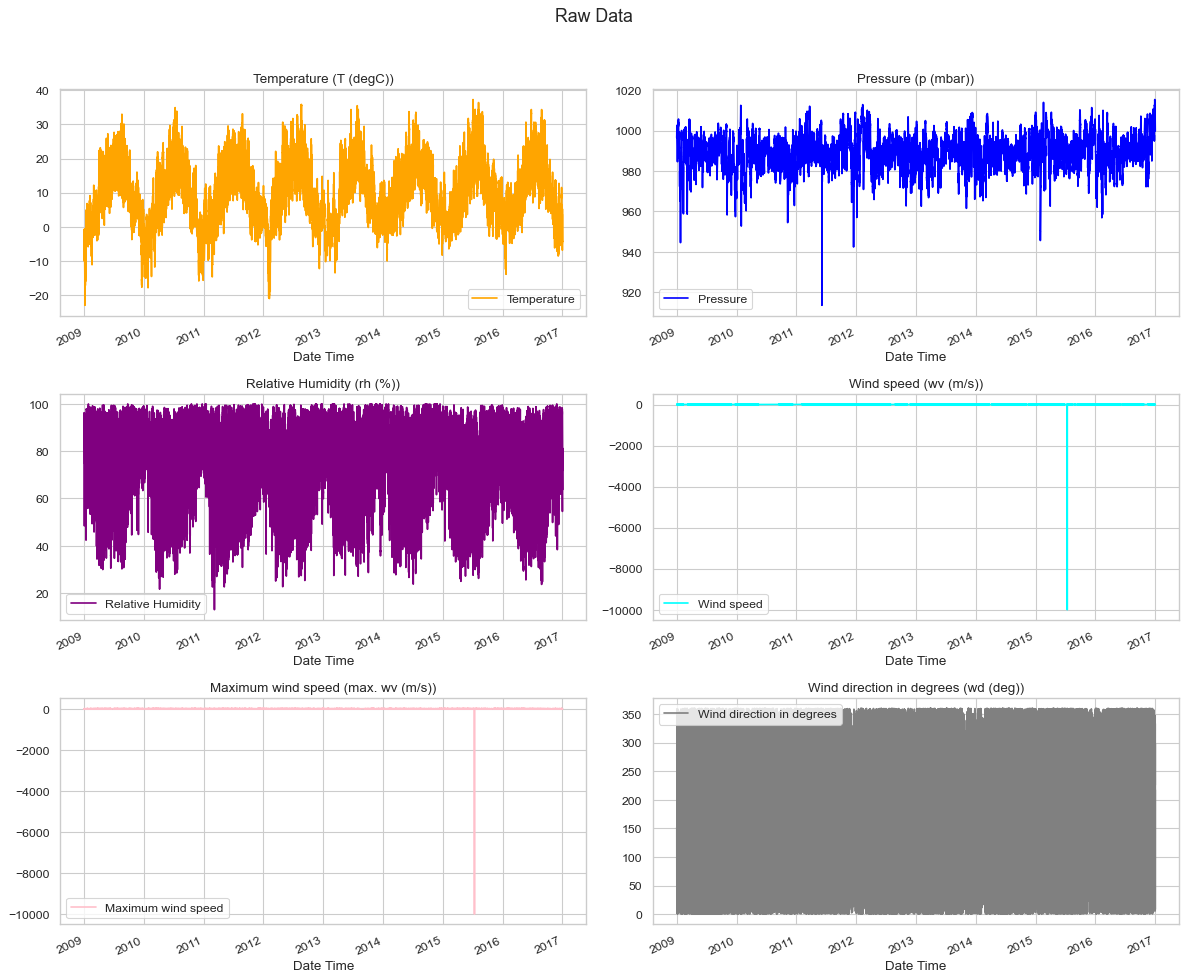

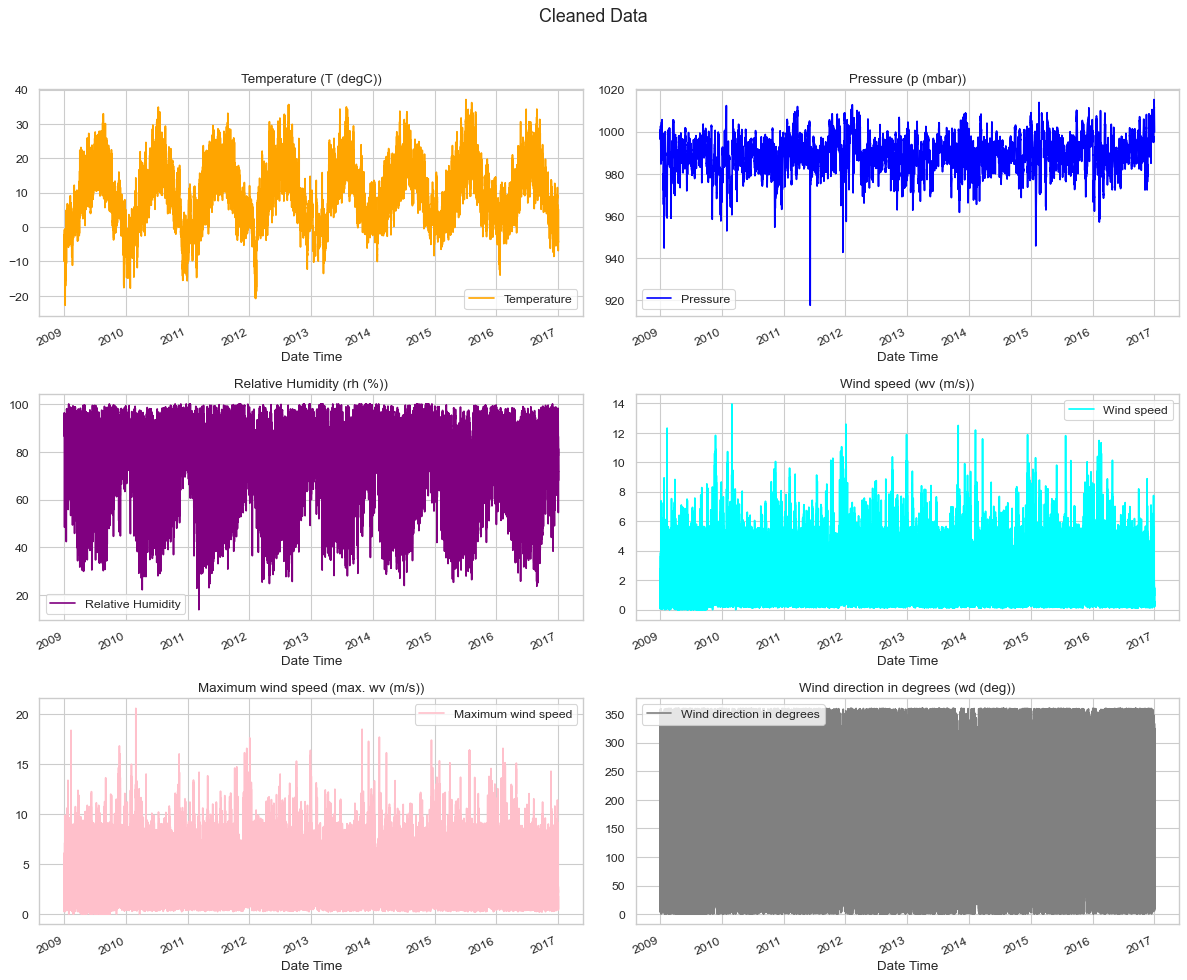

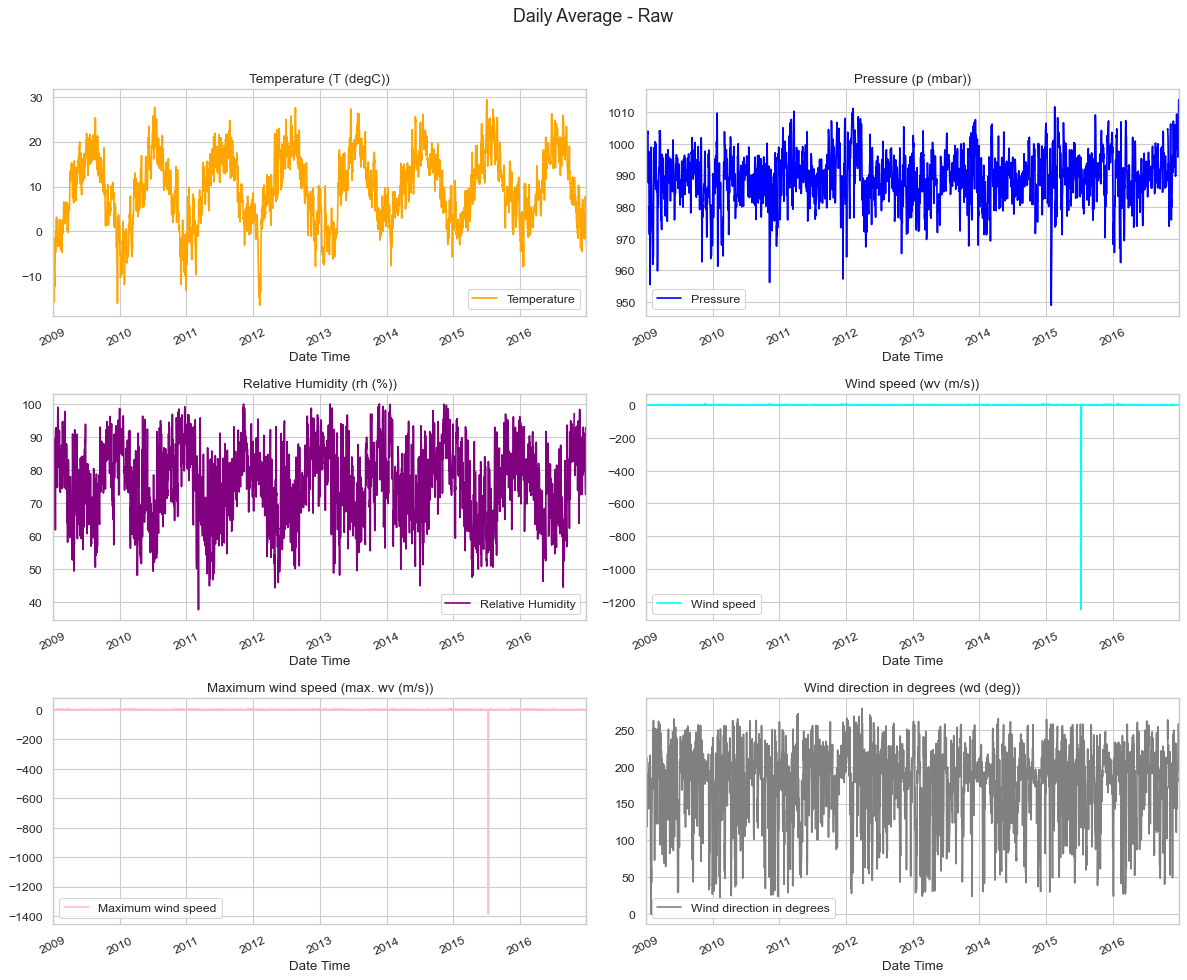

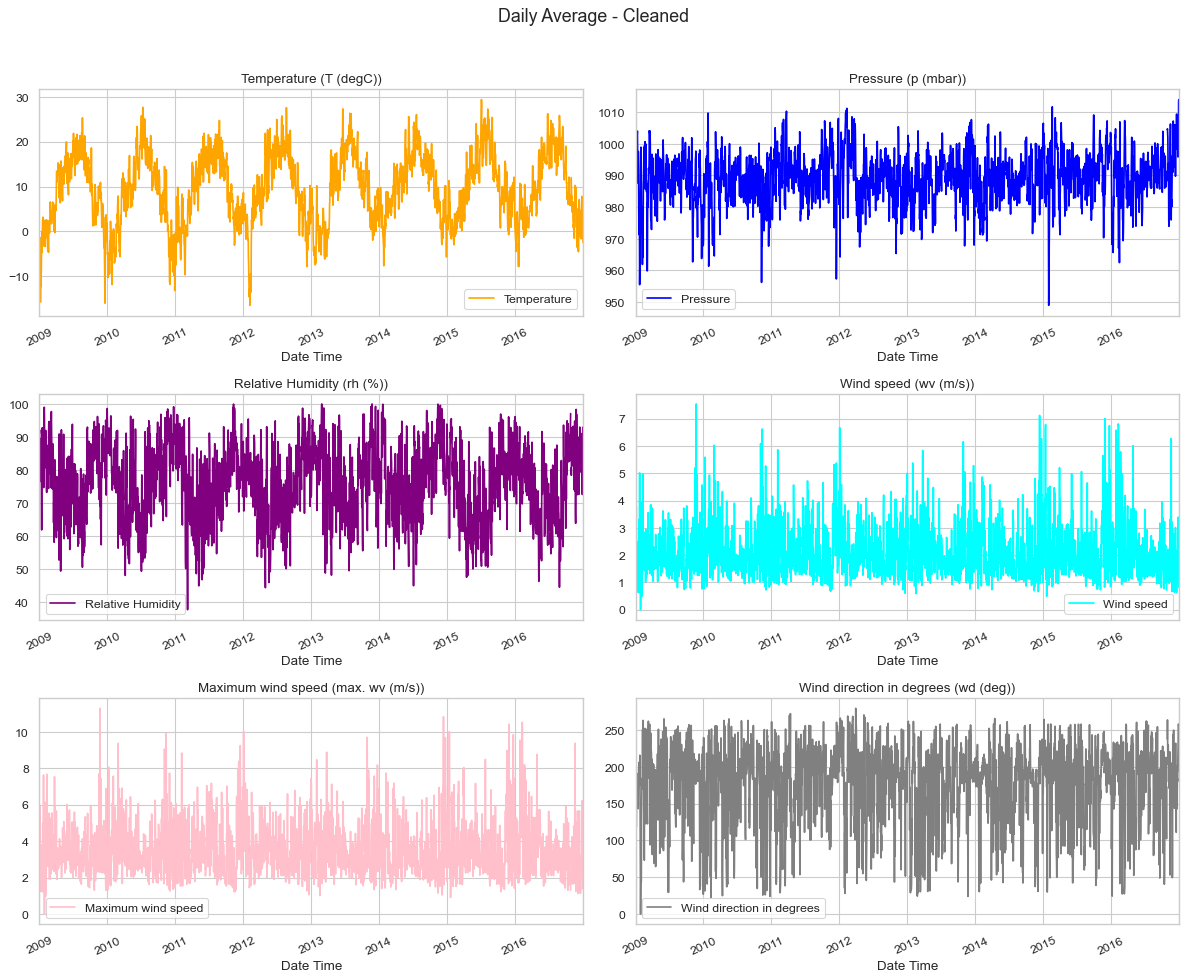

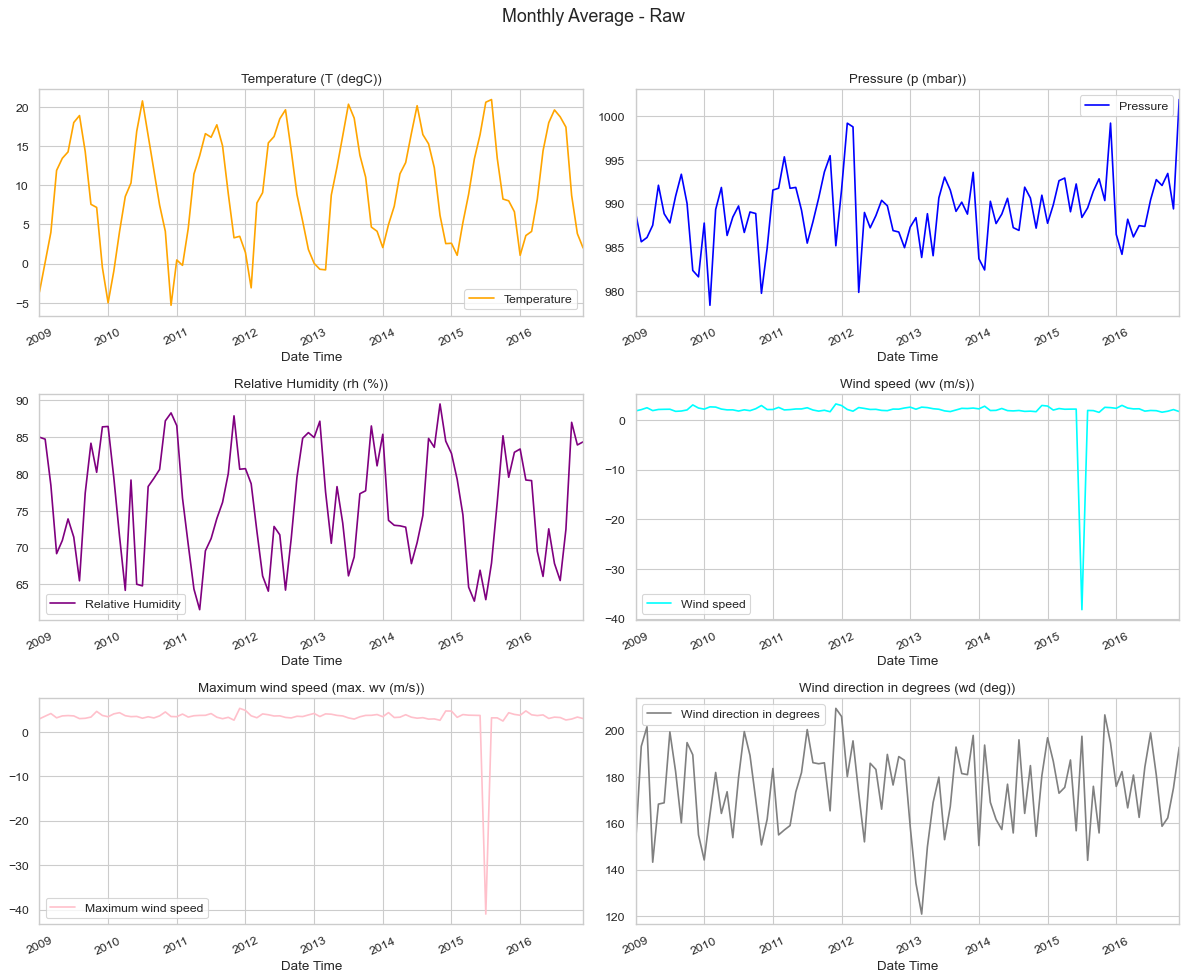

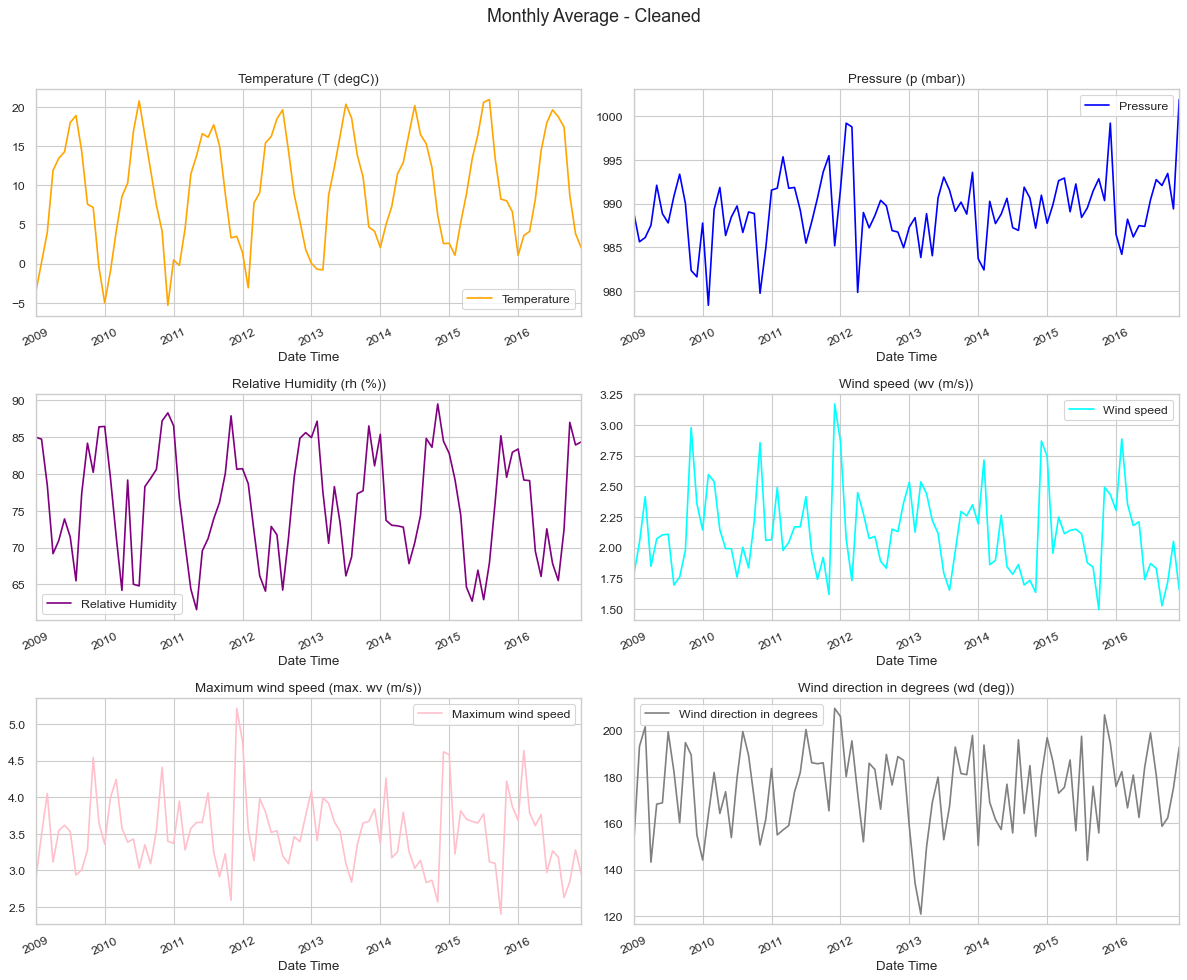

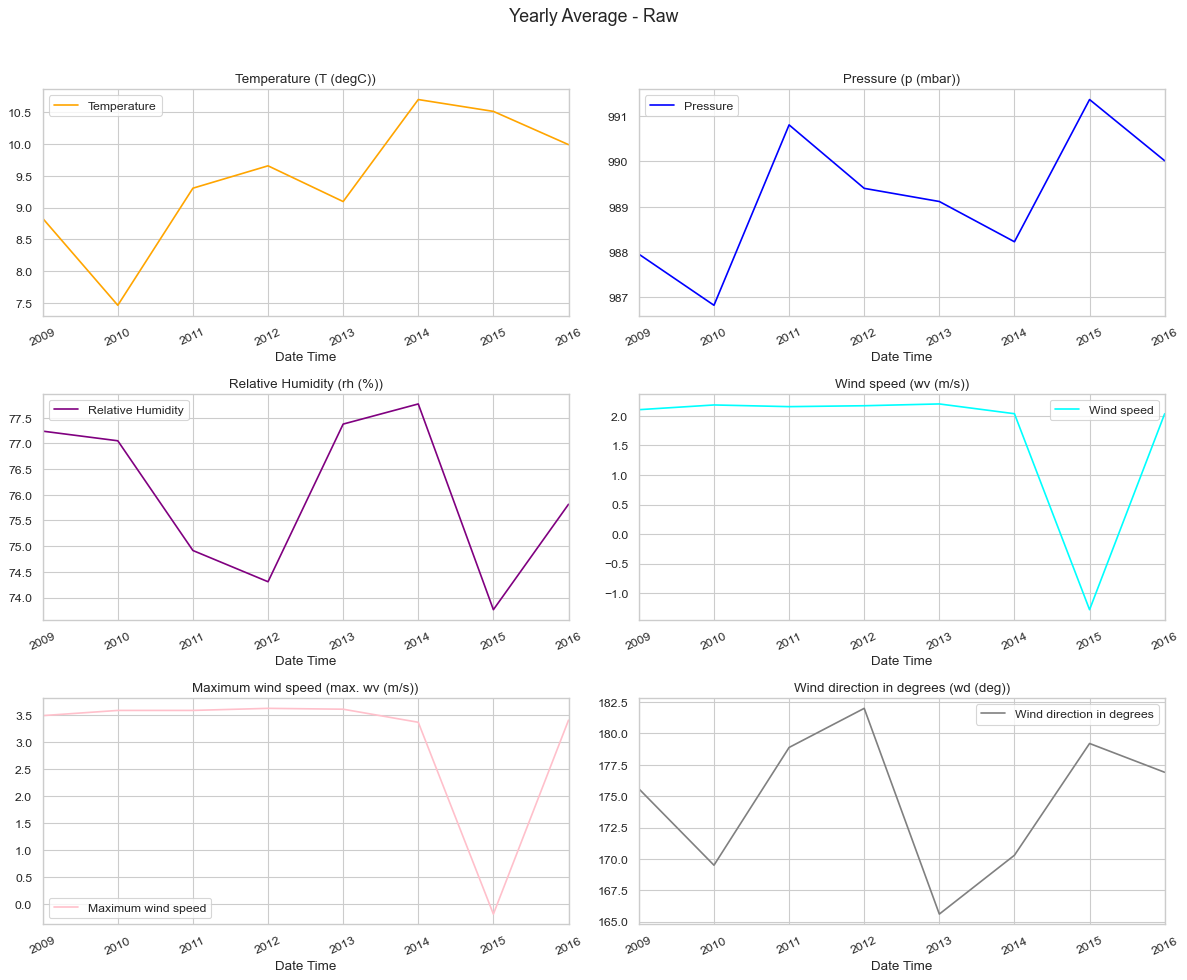

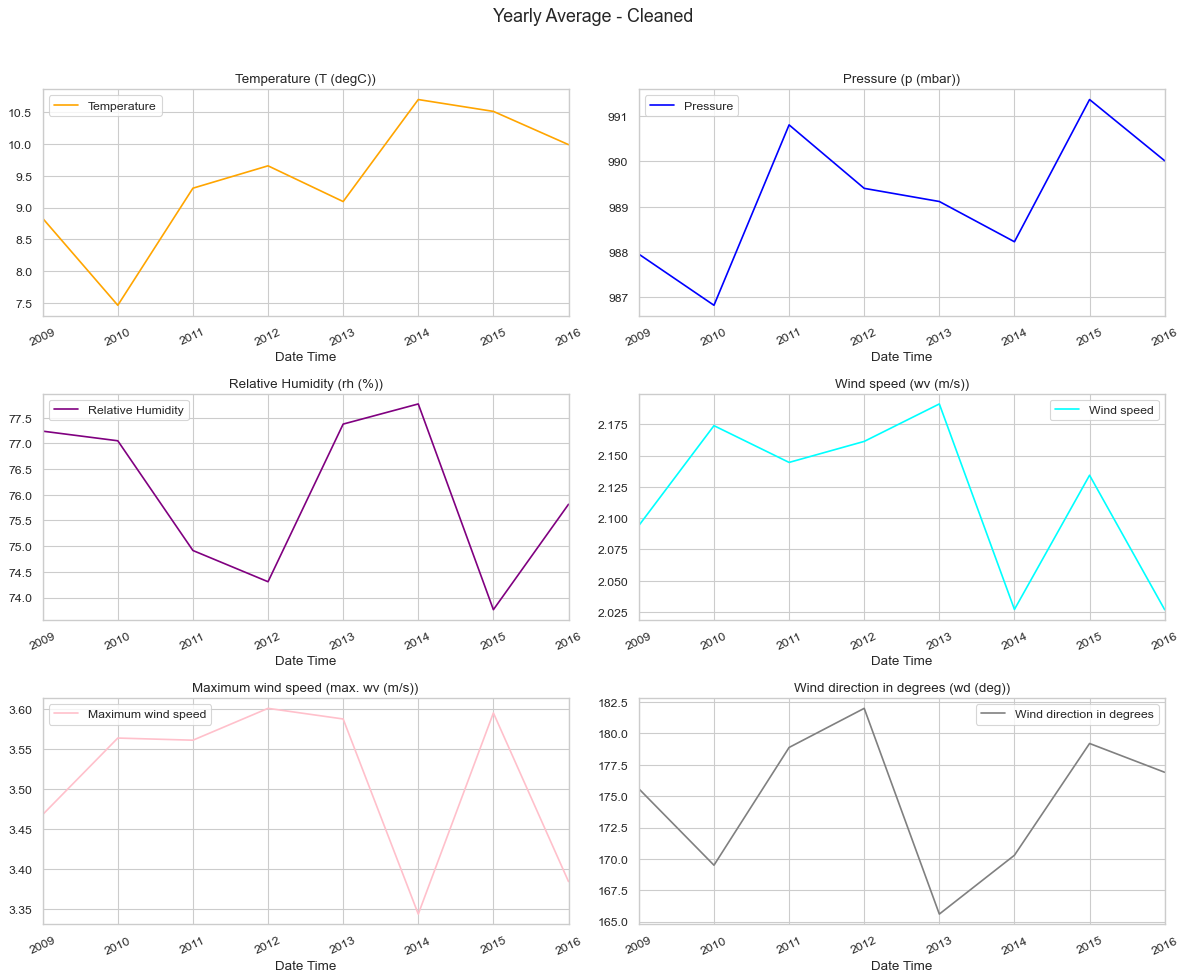

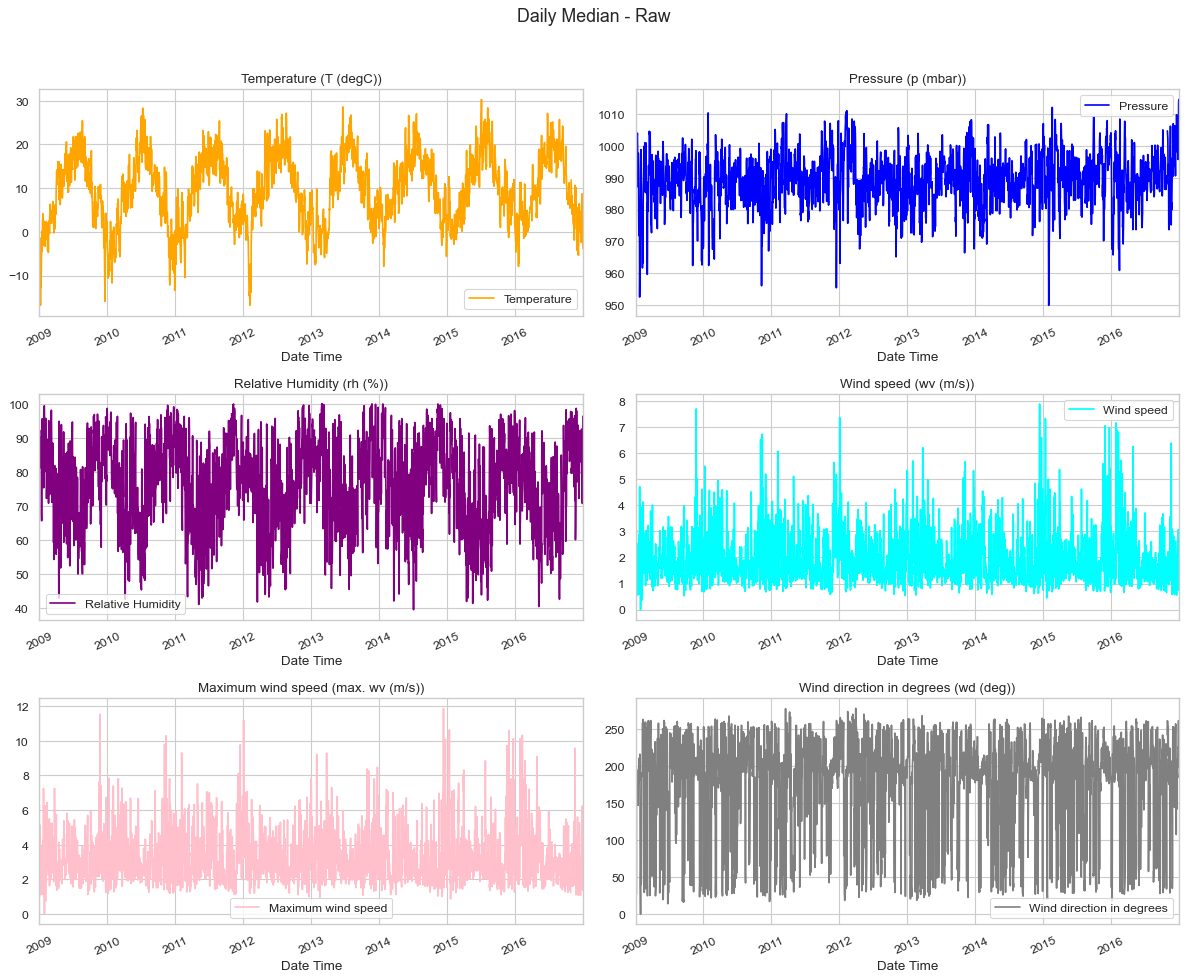

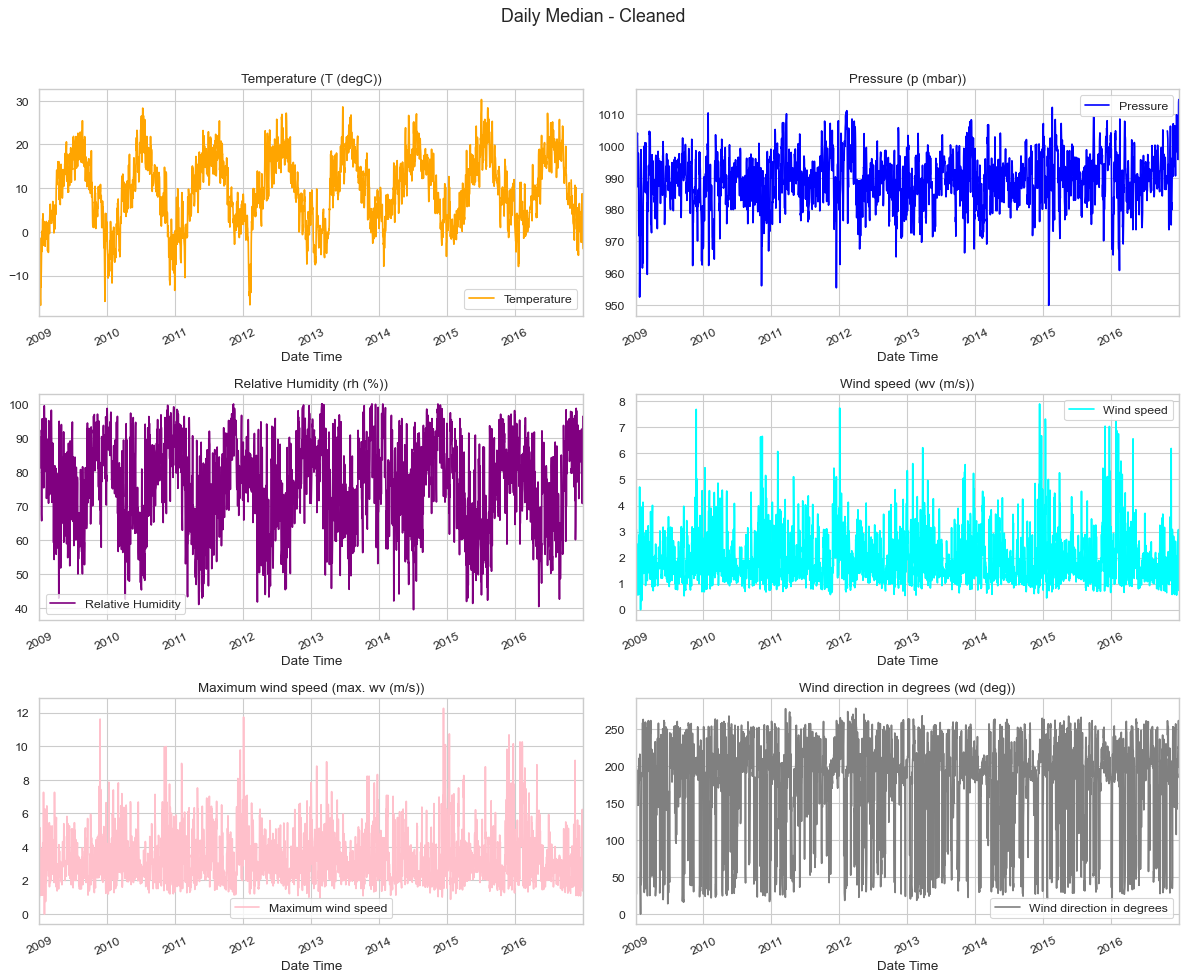

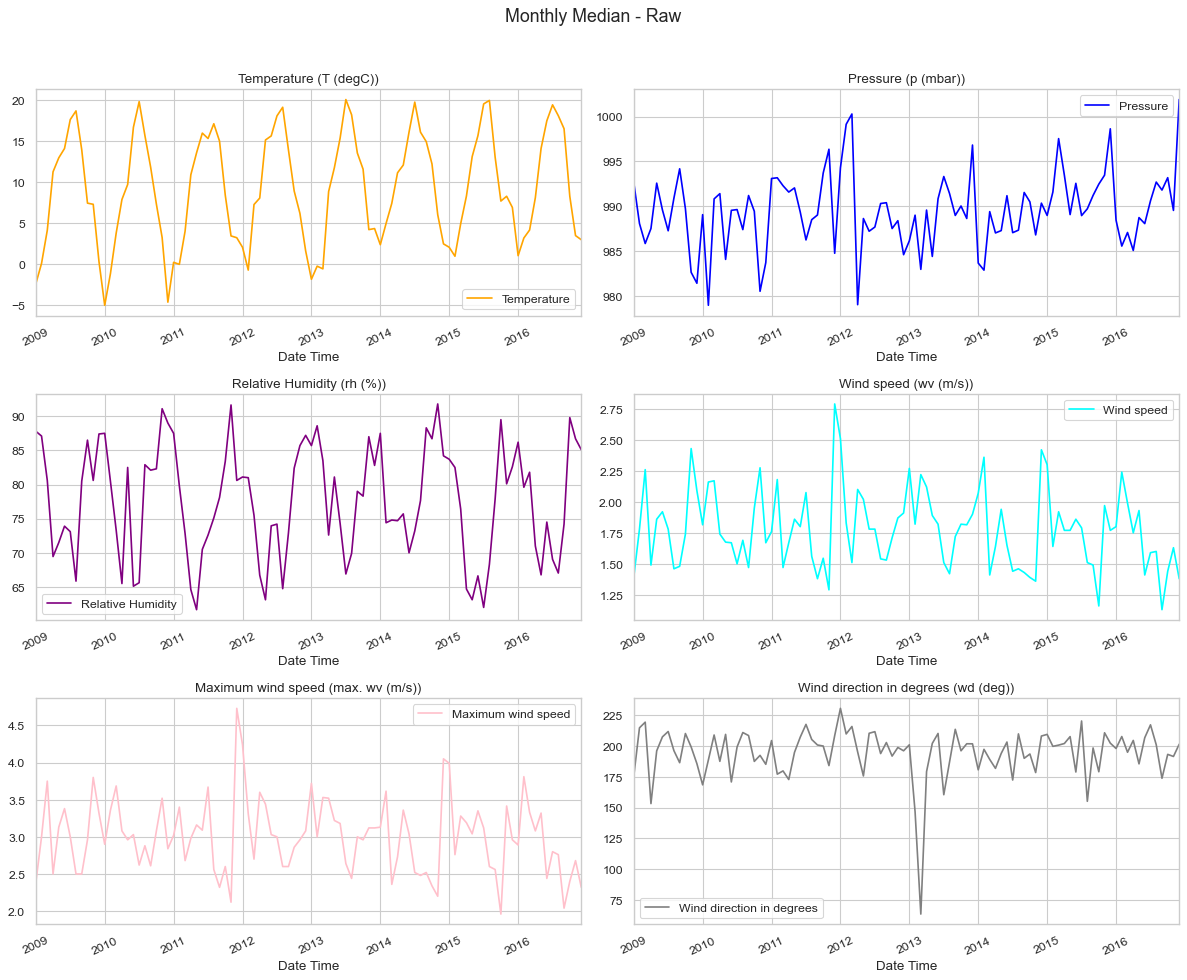

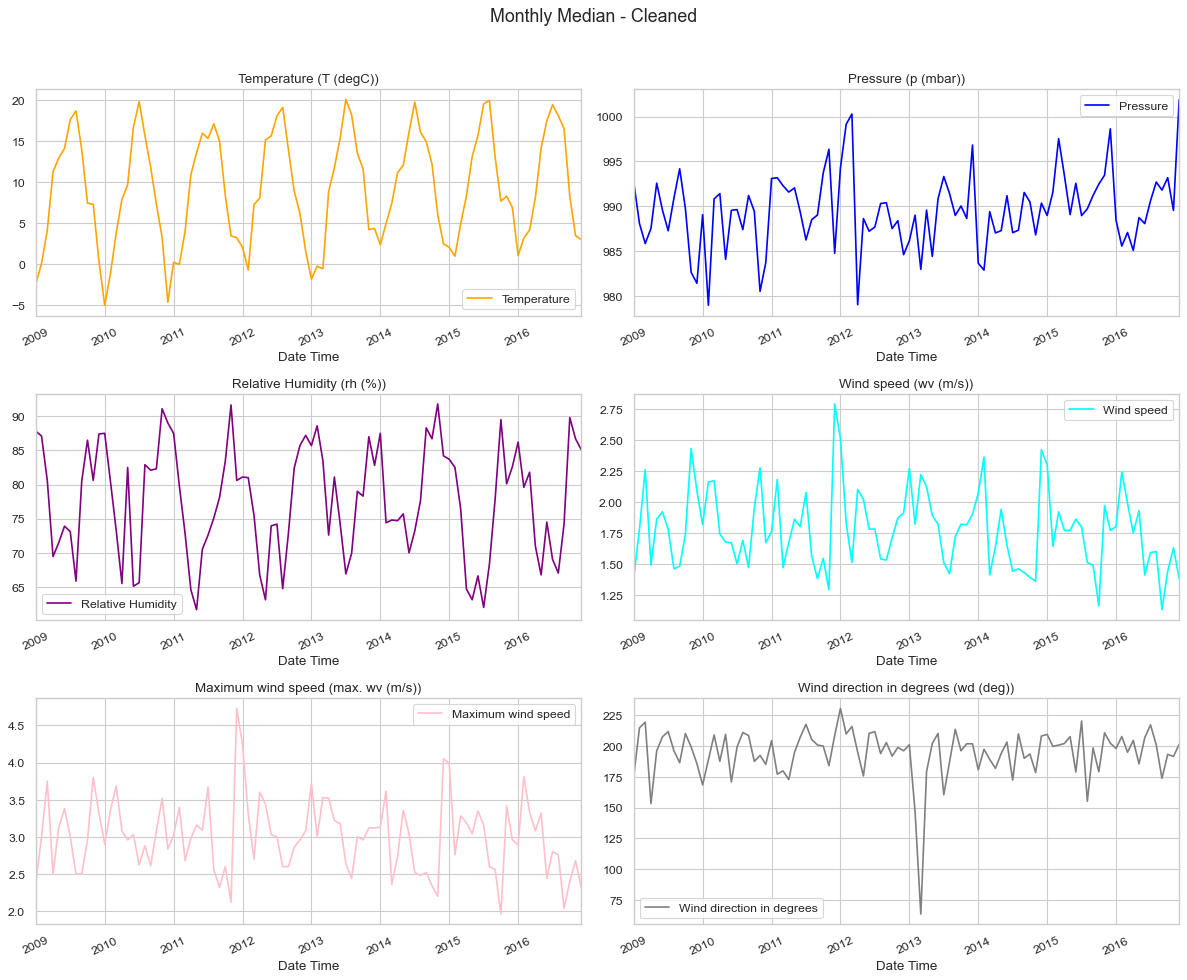

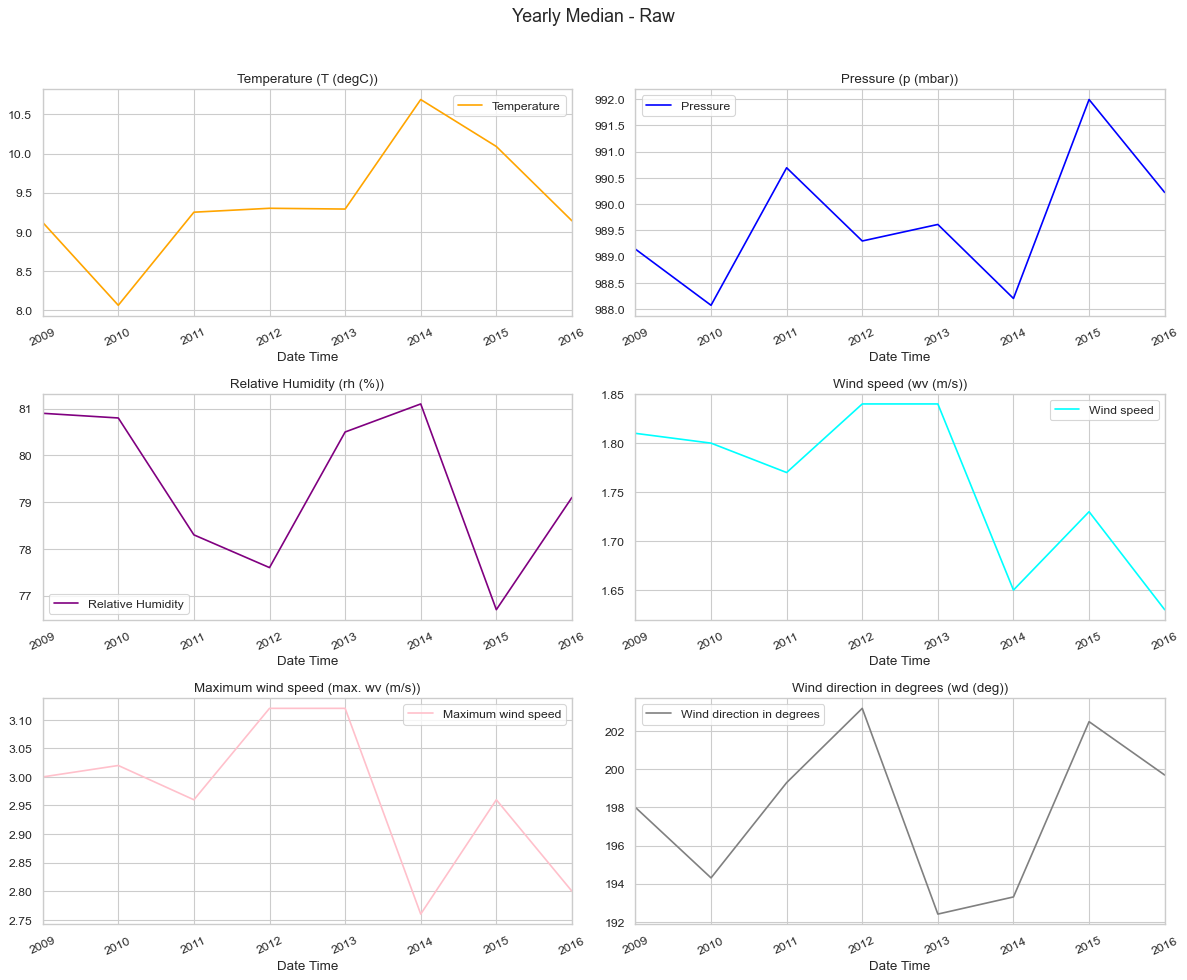

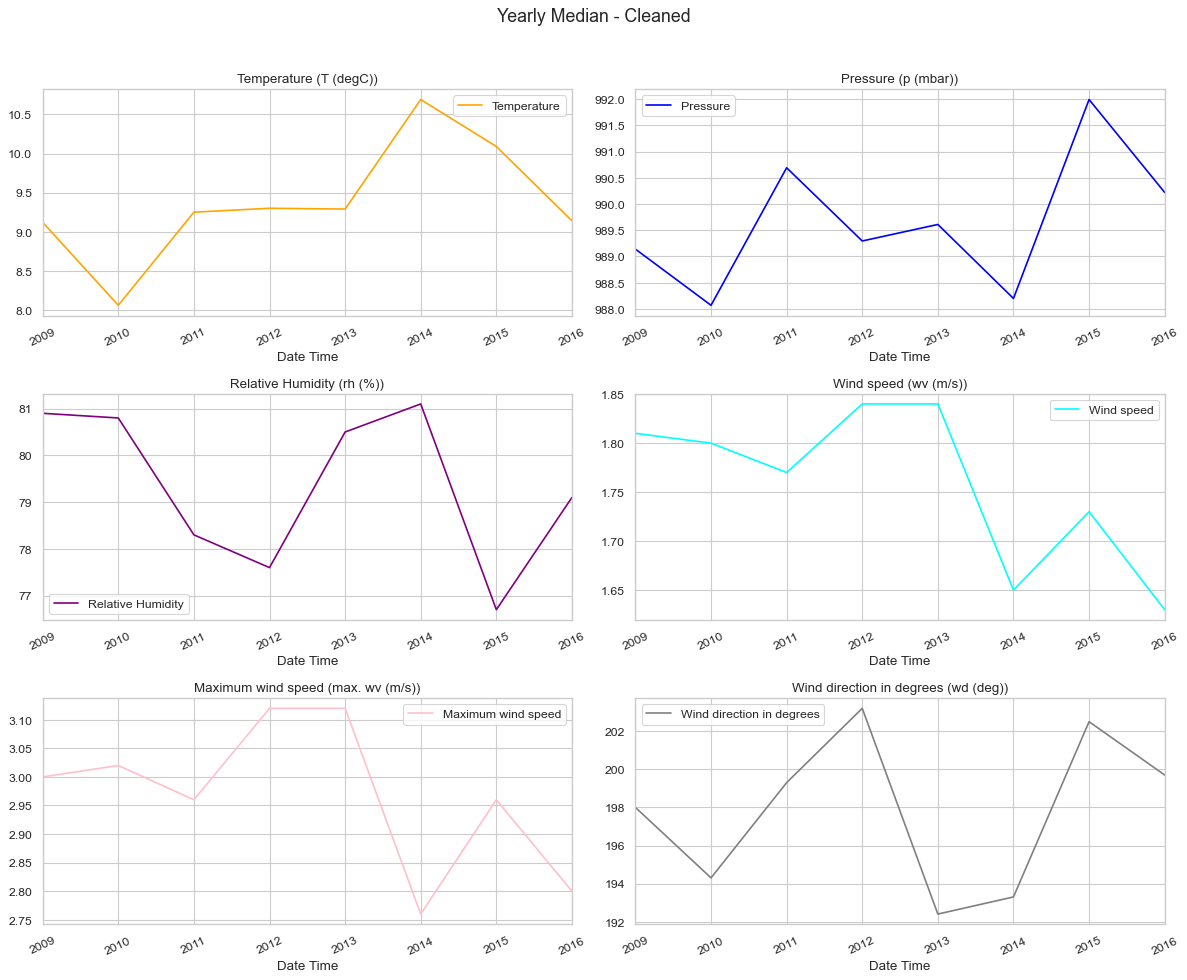

In [60]:
# Raw Data
show_raw_visualization(df_dict["df_unclean"], cols_dict, date_time_key, "Raw Data")
show_raw_visualization(df_dict["df_clean"], cols_dict, date_time_key, "Cleaned Data")

# Daily Average
show_raw_visualization(df_dict["df_day_average"], cols_dict, date_time_key, "Daily Average - Raw")
show_raw_visualization(df_dict["df_clean_day_average"], cols_dict, date_time_key, "Daily Average - Cleaned")

# Monthly Average
show_raw_visualization(df_dict["df_month_average"], cols_dict, date_time_key, "Monthly Average - Raw")
show_raw_visualization(df_dict["df_clean_month_average"], cols_dict, date_time_key, "Monthly Average - Cleaned")

# Yearly Average
show_raw_visualization(df_dict["df_year_average"], cols_dict, date_time_key, "Yearly Average - Raw")
show_raw_visualization(df_dict["df_clean_year_average"], cols_dict, date_time_key, "Yearly Average - Cleaned")

# Daily Median
show_raw_visualization(df_dict["df_day_median"], cols_dict, date_time_key, "Daily Median - Raw")
show_raw_visualization(df_dict["df_clean_day_median"], cols_dict, date_time_key, "Daily Median - Cleaned")

# Monthly Median
show_raw_visualization(df_dict["df_month_median"], cols_dict, date_time_key, "Monthly Median - Raw")
show_raw_visualization(df_dict["df_clean_month_median"], cols_dict, date_time_key, "Monthly Median - Cleaned")

# Yearly Median
show_raw_visualization(df_dict["df_year_median"], cols_dict, date_time_key, "Yearly Median - Raw")
show_raw_visualization(df_dict["df_clean_year_median"], cols_dict, date_time_key, "Yearly Median - Cleaned")

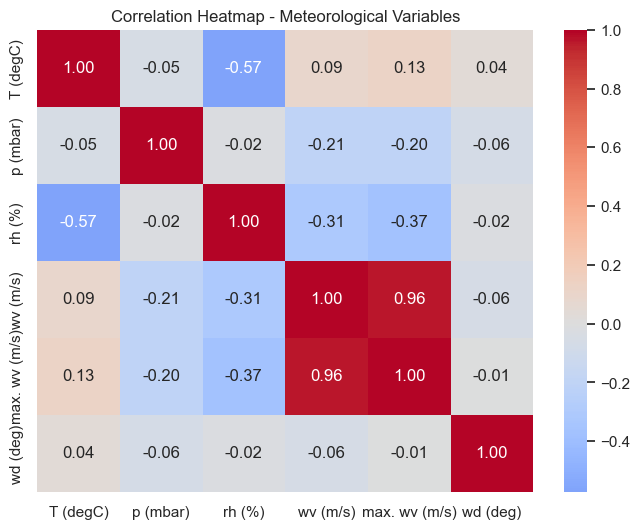

In [61]:
def show_correlation_heatmap(df, cols_dict, title="Correlation Heatmap - Meteorological Variables"):
    """
    Display a correlation heatmap for all numeric variables in cols_dict,
    excluding the 'Date Time' column.
    """
    # Select feature columns (exclude date column)
    feature_cols = [col for col in cols_dict if col != "Date Time"]
    
    # Compute correlation matrix
    corr_matrix = df[feature_cols].corr()
    
    # Plot heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title(title)
    plt.show()

# Show heatmap
show_correlation_heatmap(df_clean, cols_dict)

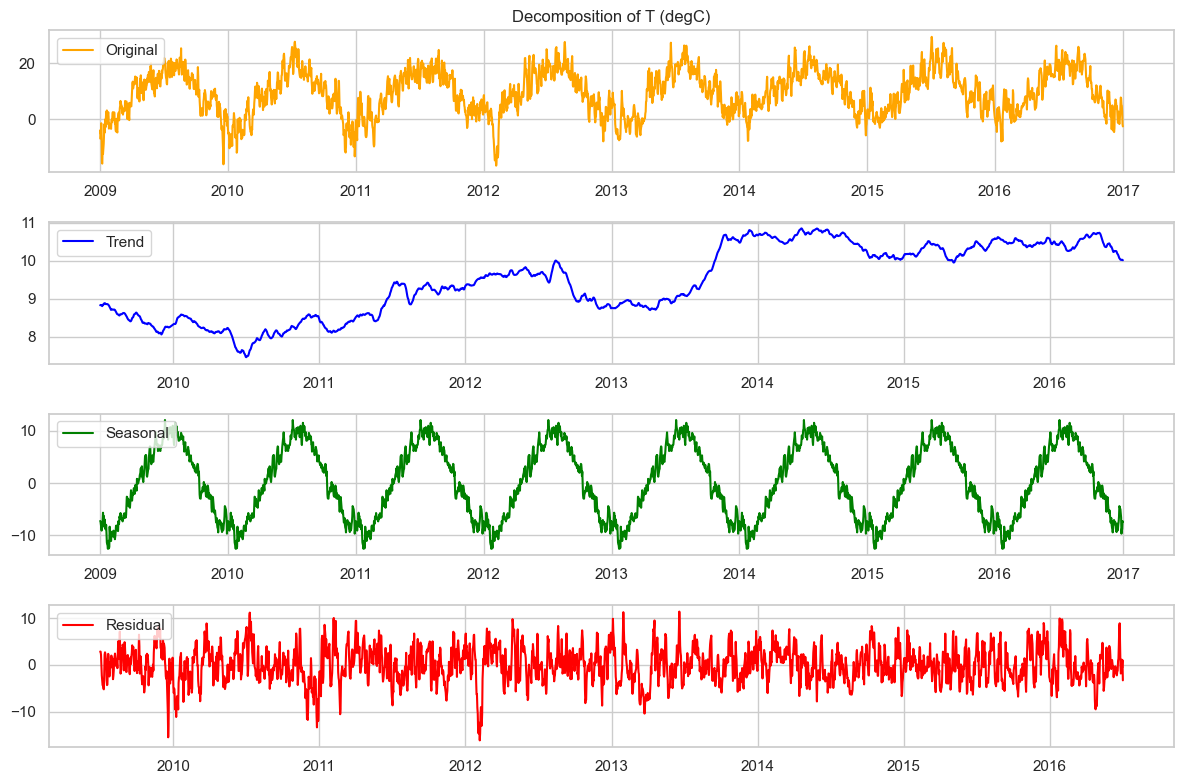

In [62]:
def show_decompose(df, col_name, cols_dict, freq='D', period=365):
    """
    Decompose a time series into trend, seasonal, and residual components
    and display the plots.
    """
    
    # Select time series
    ts = df.set_index('Date Time')[col_name].resample(freq).mean()
    
    # Fill missing values
    ts = ts.interpolate(method='linear')

    # Additive decomposition
    decomposition = seasonal_decompose(ts, model='additive', period=period)
    
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid
    
    # Column color from metadata
    color_col = cols_dict[col_name]['color'] if col_name in cols_dict else 'black'
    
    # Plot components
    plt.figure(figsize=(12,8))
    
    plt.subplot(4,1,1)
    plt.plot(ts, label='Original', color=color_col)
    plt.title(f"Decomposition of {col_name}")
    plt.legend(loc='upper left')
    
    plt.subplot(4,1,2)
    plt.plot(trend, label='Trend', color='blue')
    plt.legend(loc='upper left')
    
    plt.subplot(4,1,3)
    plt.plot(seasonal, label='Seasonal', color='green')
    plt.legend(loc='upper left')
    
    plt.subplot(4,1,4)
    plt.plot(residual, label='Residual', color='red')
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Temperature decomposition
show_decompose(df_clean, 'T (degC)', cols_dict, freq='D', period=365)

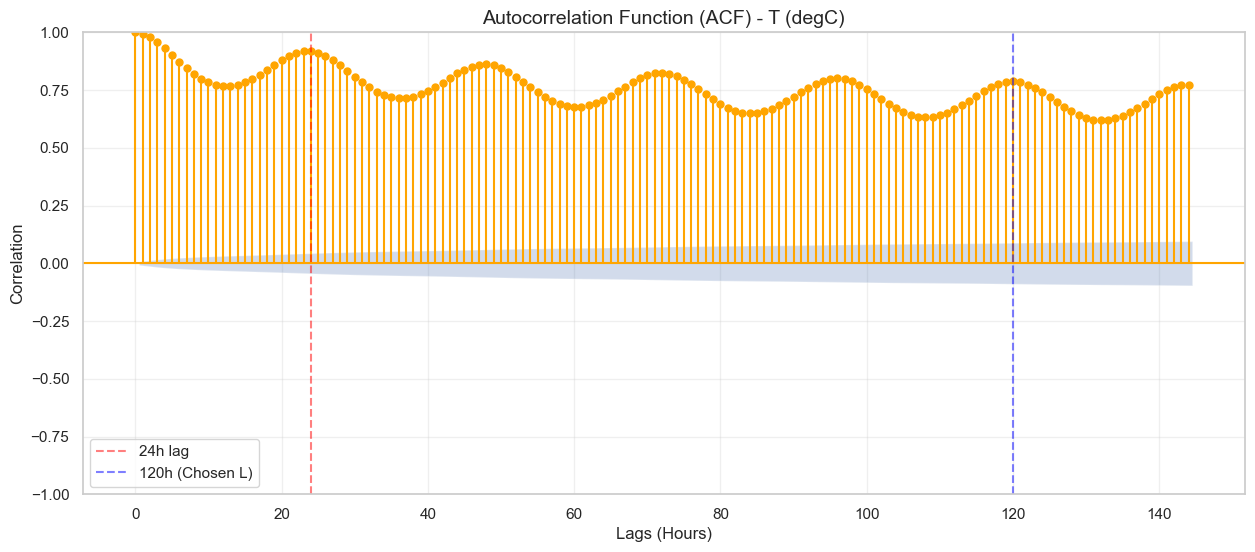

In [63]:
def perform_lag_analysis(df, column='T (degC)', resample_freq='h', lags=144):
    """
    Analyze the autocorrelation of a time series to justify the lookback window (L).
    144 hourly lags ≈ 6 days.
    """
    # Resample to hourly resolution
    series = df.set_index('Date Time')[column].resample(resample_freq).mean().dropna()
    
    # Plot ACF
    plt.figure(figsize=(15, 6))
    plot_acf(series, lags=lags, ax=plt.gca(), color='orange',
             vlines_kwargs={"colors": 'orange'})
    
    # Improve readability
    plt.title(f"Autocorrelation Function (ACF) - {column}", fontsize=14)
    plt.xlabel("Lags (Hours)")
    plt.ylabel("Correlation")
    plt.axvline(x=24, color='red', linestyle='--', alpha=0.5, label='24h lag')
    plt.axvline(x=120, color='blue', linestyle='--', alpha=0.5, label='120h (Chosen L)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

perform_lag_analysis(df_dict["df_clean"])

### 5. Modeling

In [19]:
# Print all DataFrame names stored in df_dict
print("DataFrames in df_dict:")
for name in df_dict.keys():
    print("-", name)

DataFrames in df_dict:
- df_unclean
- df_clean
- df_day_average
- df_clean_day_average
- df_month_average
- df_clean_month_average
- df_year_average
- df_clean_year_average
- df_day_median
- df_clean_day_median
- df_month_median
- df_clean_month_median
- df_year_median
- df_clean_year_median


In [ ]:
# Select DataFrame version for training
DF_VERSION = "df_clean"            # choose from df_dict keys
df = df_dict[DF_VERSION].copy()

# Lookback & Horizon Parameters
L = 120                              # lookback window (previous 120 steps)
H = 24                               # prediction horizon (24 steps ahead)
RESAMPLE = 'h'                       # resampling frequency ('h' = hourly)

# Model Hyperparameters
HIDDEN_DIM = 64                       # hidden layer dimension
N_LAYERS = 2                          # number of layers
N_HEADS = 4                           # only for Transformer models

# Columns
# Exclude datetime and wind direction from features
METEO_COLS = [col for col in cols_dict.keys() if col not in [date_time_key, 'wd (deg)']]

# Include cyclic time and wind features
CYCLIC_COLS = ['day_sin', 'day_cos', 'year_sin', 'year_cos', 'wd_sin', 'wd_cos']

FEATURE_COLS = METEO_COLS + CYCLIC_COLS
TARGET_COL = 'T (degC)'
N_FEATURES = len(FEATURE_COLS)
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

# Training Parameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Selected DataFrame for training: {DF_VERSION} -> {df.shape}")
print(f"Number of features: {N_FEATURES}, Target index: {TARGET_IDX}")

Selected DataFrame for training: df_unclean -> (420223, 7)
Number of features: 11, Target index: 0


In [66]:
def apply_cyclic_features(df):
    """
    Transform time and wind direction into cyclical (sin/cos) features.
    """
    df = df.copy()
    
    # Ensure datetime
    df[date_time_key] = pd.to_datetime(df[date_time_key])
    ts_s = df[date_time_key].map(pd.Timestamp.timestamp)
    
    # Daily & yearly cycles
    day_sec = 24*60*60
    year_sec = 365.2425*day_sec
    
    df['day_sin'] = np.sin(ts_s * 2*np.pi/day_sec)
    df['day_cos'] = np.cos(ts_s * 2*np.pi/day_sec)
    df['year_sin'] = np.sin(ts_s * 2*np.pi/year_sec)
    df['year_cos'] = np.cos(ts_s * 2*np.pi/year_sec)
    
    # Wind direction cycle
    wd_rad = df['wd (deg)'] * np.pi / 180
    df['wd_sin'] = np.sin(wd_rad)
    df['wd_cos'] = np.cos(wd_rad)
    
    return df

def prepare_training_data(df, resample_freq, L, H, target_idx):
    """
    Prepare sequences and normalize features for training/validation/test.
    """
    # Resample
    df_resampled = df.set_index(date_time_key).resample(resample_freq).mean().dropna().reset_index()
    
    # Apply cyclical features
    df_final = apply_cyclic_features(df_resampled)
    
    # Chronological split: 70% train, 15% val, 15% test
    n = len(df_final)
    train_df = df_final[:int(n*0.7)]
    val_df = df_final[int(n*0.7):int(n*0.85)]
    test_df = df_final[int(n*0.85):]
    
    # Feature normalization (fit only on train)
    scaler = StandardScaler()
    train_data = scaler.fit_transform(train_df[FEATURE_COLS])
    val_data = scaler.transform(val_df[FEATURE_COLS])
    test_data = scaler.transform(test_df[FEATURE_COLS])
    
    # Create sequences
    def create_sequences(data, L, H, target_idx):
        X, y = [], []
        for i in range(len(data) - L - H + 1):
            X.append(data[i:i+L])
            y.append(data[i+L:i+L+H, target_idx])
        return torch.tensor(np.array(X), dtype=torch.float32), \
               torch.tensor(np.array(y), dtype=torch.float32)
    
    X_train, y_train = create_sequences(train_data, L, H, target_idx)
    X_val, y_val = create_sequences(val_data, L, H, target_idx)
    X_test, y_test = create_sequences(test_data, L, H, target_idx)
    
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

# Prepare data for model
X_train, y_train, X_val, y_val, X_test, y_test, dataset_scaler = prepare_training_data(
    df, RESAMPLE, L, H, TARGET_IDX
)

In [68]:
# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of batches (Train): {len(train_loader)}")

class EarlyStopping:
    """
    Early stops the training if validation loss doesn't improve after a given patience.
    """
    def __init__(self, patience=5, min_delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        """Saves model when validation loss decreases."""
        torch.save(model.state_dict(), self.path)

Number of batches (Train): 764


In [69]:
class GRUForecaster(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        super(GRUForecaster, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, 
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        out, h_n = self.gru(x)
        
        # Take only the last time step
        last_step = out[:, -1, :] 
        
        # Predict next H steps
        return self.fc(last_step)

# Instantiate GRU model
gru_model = GRUForecaster(N_FEATURES, HIDDEN_DIM, N_LAYERS, H).to(DEVICE)

In [70]:
# Transformer Forecaster
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerForecaster(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, output_dim, dropout=0.1):
        super(TransformerForecaster, self).__init__()
        
        # Input projection: transform features into model dimension
        self.encoder_input = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                   dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output layer
        self.decoder = nn.Linear(d_model, output_dim)
        
    def forward(self, x):
        # Input projection and positional encoding
        x = self.encoder_input(x)  # (Batch, Seq_Length, d_model)
        x = self.pos_encoder(x)
        
        # Global attention via transformer
        x = self.transformer_encoder(x)
        
        # Pooling: mean over sequence dimension (alternative: last step)
        x = x.mean(dim=1) 
        
        # Predict next H steps
        return self.decoder(x)

# Instantiate Transformer model
transformer_model = TransformerForecaster(N_FEATURES, HIDDEN_DIM, N_HEADS, N_LAYERS, H).to(DEVICE)

In [71]:
# Loss function
criterion = nn.MSELoss()  # Mean Squared Error for regression

# Optimizers
gru_optimizer = optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)
tf_optimizer = optim.Adam(transformer_model.parameters(), lr=LEARNING_RATE)

print(f"Models ready on device: {DEVICE}")

Models ready on device: cuda


In [72]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs, device, model_name="model"):
    history = {'train_loss': [], 'val_loss': []}
    early_stopping = EarlyStopping(patience=7, path=os.path.join(output_path, f'best_{model_name}.pt'))
    
    print(f"\nStarting training for {model_name}...")
    
    for epoch in range(1, epochs + 1):
        # TRAINING 
        model.train()
        train_losses = []
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            
        # VALIDATION 
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch [{epoch}/{epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # Early Stopping
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch}. Restoring best model...")
            model.load_state_dict(torch.load(early_stopping.path))
            break
            
    return history


In [73]:
# 1. Train GRU
gru_history = train_model(
    gru_model, train_loader, val_loader, 
    gru_optimizer, criterion, EPOCHS, DEVICE, "GRU"
)

# 2. Train Transformer
transformer_history = train_model(
    transformer_model, train_loader, val_loader, 
    tf_optimizer, criterion, EPOCHS, DEVICE, "Transformer"
)


Starting training for GRU...
Epoch [1/50] - Train Loss: 0.1146 | Val Loss: 0.0813
Epoch [5/50] - Train Loss: 0.0632 | Val Loss: 0.0737
Epoch [10/50] - Train Loss: 0.0397 | Val Loss: 0.0933
Early stopping at epoch 10. Restoring best model...

Starting training for Transformer...


C:\Users\joaov\AppData\Local\Temp\ipykernel_394544\3481366787.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(early_stopping.path))


Epoch [1/50] - Train Loss: 0.1162 | Val Loss: 0.0960
Epoch [5/50] - Train Loss: 0.0476 | Val Loss: 0.1450
Early stopping at epoch 8. Restoring best model...


### 6. Evaluetion

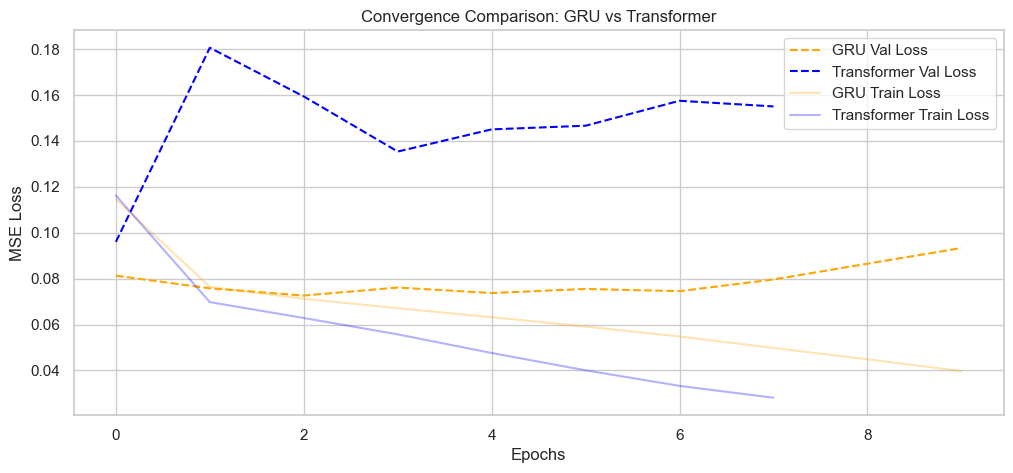

In [74]:
# Plot Learning Curves
def plot_learning_curves(gru_hist, tf_hist):
    plt.figure(figsize=(12, 5))
    
    # Validation Loss
    plt.plot(gru_hist['val_loss'], label='GRU Val Loss', color='orange', linestyle='--')
    plt.plot(tf_hist['val_loss'], label='Transformer Val Loss', color='blue', linestyle='--')
    
    # Training Loss (faded)
    plt.plot(gru_hist['train_loss'], label='GRU Train Loss', color='orange', alpha=0.3)
    plt.plot(tf_hist['train_loss'], label='Transformer Train Loss', color='blue', alpha=0.3)
    
    plt.title("Convergence Comparison: GRU vs Transformer")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curves(gru_history, transformer_history)

In [76]:
# Evaluate and Denormalize Predictions
def evaluate_and_denormalize(model, loader, scaler, target_idx, device):
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(batch_y.numpy())
    
    preds_norm = np.concatenate(all_preds, axis=0)
    targets_norm = np.concatenate(all_targets, axis=0)

    # Função auxiliar para inverter normalização
    def invert(data_2d):
        dummy = np.zeros((data_2d.shape[0] * data_2d.shape[1], len(FEATURE_COLS)))
        dummy[:, target_idx] = data_2d.flatten()
        inverted = scaler.inverse_transform(dummy)[:, target_idx]
        return inverted.reshape(data_2d.shape)

    return invert(preds_norm), invert(targets_norm)

# Generate Test Set Predictions
gru_preds, targets = evaluate_and_denormalize(gru_model, test_loader, dataset_scaler, TARGET_IDX, DEVICE)
tf_preds, _ = evaluate_and_denormalize(transformer_model, test_loader, dataset_scaler, TARGET_IDX, DEVICE)

In [ ]:
# Compute Performance Metrics
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true.flatten(), y_pred.flatten())
    return mae, rmse, r2

gru_metrics = calculate_metrics(targets, gru_preds)
tf_metrics = calculate_metrics(targets, tf_preds)

metrics_df = pd.DataFrame({
    'Metric': ['MAE (°C)', 'RMSE (°C)', 'R² Score'],
    'GRU': gru_metrics,
    'Transformer': tf_metrics
})

print("Comparative Performance Table (Test Set):")
display(metrics_df)

Comparative Performance Table (Test Set):


,Metric,GRU,Transformer
0,MAE (°C),1.669433,1.971091
1,RMSE (°C),2.220339,2.611897
2,R² Score,0.919237,0.888240


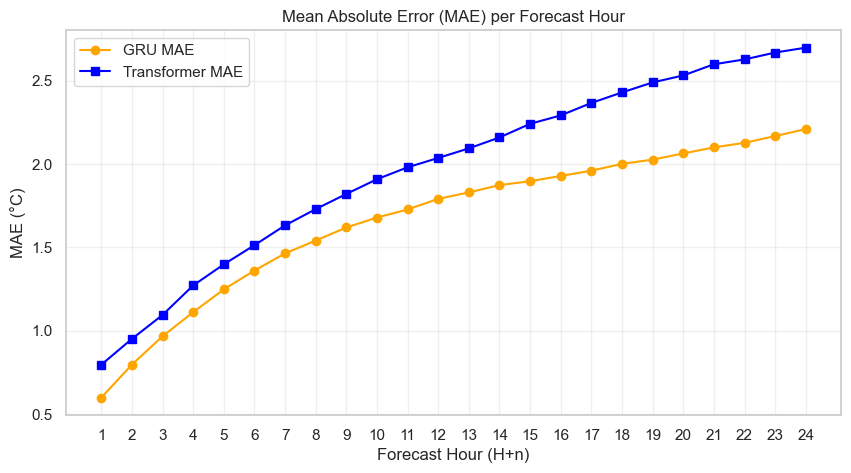

In [ ]:
# Plot Error over Prediction Horizon
def plot_error_over_horizon(y_true, gru_pred, tf_pred):
    gru_mae_per_hour = [mean_absolute_error(y_true[:, i], gru_pred[:, i]) for i in range(H)]
    tf_mae_per_hour = [mean_absolute_error(y_true[:, i], tf_pred[:, i]) for i in range(H)]
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, H+1), gru_mae_per_hour, label='GRU MAE', marker='o', color='orange')
    plt.plot(range(1, H+1), tf_mae_per_hour, label='Transformer MAE', marker='s', color='blue')
    
    plt.title("Mean Absolute Error (MAE) per Forecast Hour")
    plt.xlabel("Forecast Hour (H+n)")
    plt.ylabel("MAE (°C)")
    plt.xticks(range(1, H+1))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_error_over_horizon(targets, gru_preds, tf_preds)

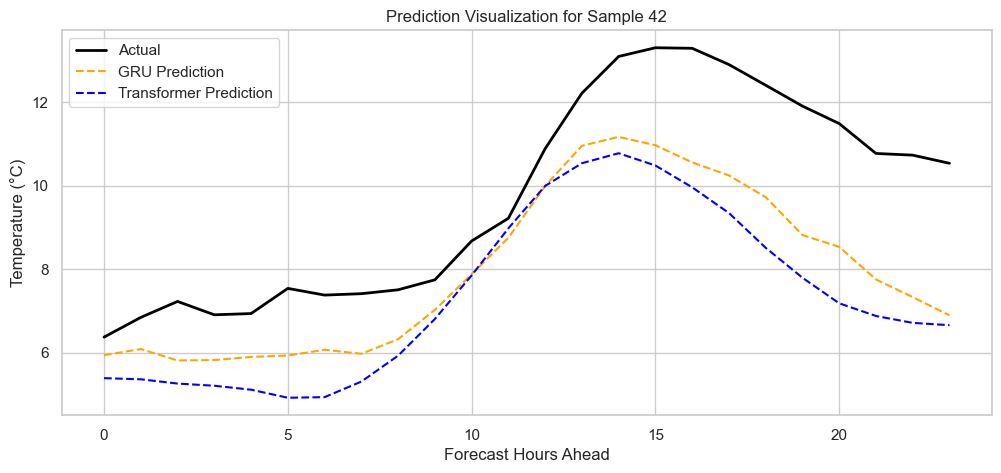

In [ ]:
# Plot Single Sample Prediction
def plot_sample_prediction(y_true, gru_pred, tf_pred, sample_idx=0):
    plt.figure(figsize=(12, 5))
    plt.plot(y_true[sample_idx], label='Actual', color='black', linewidth=2)
    plt.plot(gru_pred[sample_idx], label='GRU Prediction', color='orange', linestyle='--')
    plt.plot(tf_pred[sample_idx], label='Transformer Prediction', color='blue', linestyle='--')
    
    plt.title(f"Prediction Visualization for Sample {sample_idx}")
    plt.xlabel("Forecast Hours Ahead")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_sample_prediction(targets, gru_preds, tf_preds, sample_idx=42)